In [3]:
import numpy as np
import pandas as pd
import pyarrow.parquet as pq
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path

RAW_DIR     = Path("/mnt/c/Research/Code/gtex-bioage/data/raw")
FIGURES_DIR = Path("/mnt/c/Research/Code/gtex-bioage/results/figures")
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

SAMPLE_ATTR   = RAW_DIR / "GTEx_Analysis_v11_Annotations_SampleAttributesDS.txt"
SUBJECT_PHENO = RAW_DIR / "GTEx_Analysis_v11_Annotations_SubjectPhenotypesDS.txt"
EXPRESSION_FILE = RAW_DIR / "GTEx_Analysis_2025-08-22_v11_RNASeQCv2.4.3_gene_tpm.parquet"

PALETTE = {
    "primary": "#4C6EF5", "secondary": "#74C0FC",
    "accent":  "#F76707", "green":    "#51CF66",
    "purple":  "#845EF7", "pink":     "#F06595",
    "teal":    "#20C997", "gray":     "#ADB5BD",
    "bg":      "#F8F9FA", "dark":     "#212529",
}

plt.rcParams.update({
    "figure.facecolor": PALETTE["bg"],
    "axes.facecolor":   "white",
    "axes.spines.top":  False,
    "axes.spines.right":False,
    "axes.titlesize":   13,
    "axes.titleweight": "bold",
    "grid.color":       "#E9ECEF",
    "grid.linewidth":   0.8,
})
print("Ready.")

Ready.


In [5]:
samples  = pd.read_csv(SAMPLE_ATTR,  sep="\t", low_memory=False)
subjects = pd.read_csv(SUBJECT_PHENO, sep="\t", low_memory=False)

samples = samples.copy()
samples["SUBJID"] = samples["SAMPID"].str.extract(r"(GTEX-[^-]+)")

meta = samples.merge(subjects, on="SUBJID", how="inner")

print(f"Sample attributes  : {samples.shape[0]:,} rows x {samples.shape[1]} columns")
print(f"Subject phenotypes : {subjects.shape[0]:,} rows x {subjects.shape[1]} columns")
print(f"Merged metadata    : {meta.shape[0]:,} samples x {meta.shape[1]} columns")
print(f"Unique subjects    : {meta['SUBJID'].nunique():,}")
print(f"Unique tissues     : {meta['SMTSD'].nunique()}")

Sample attributes  : 48,231 rows x 120 columns
Subject phenotypes : 981 rows x 4 columns
Merged metadata    : 46,379 samples x 123 columns
Unique subjects    : 980
Unique tissues     : 68


In [6]:
pf     = pq.ParquetFile(EXPRESSION_FILE)
schema = pf.schema_arrow

print(f"File size    : {EXPRESSION_FILE.stat().st_size / 1e9:.2f} GB")
print(f"Row groups   : {pf.num_row_groups}")
print(f"Total columns: {len(schema):,}  (= samples)")
print(f"First 3 cols : {schema.names[:3]}")
print(f"Last  3 cols : {schema.names[-3:]}")

# Read only 2 columns to check row count (genes) — safe, tiny
sample_cols = pq.read_table(EXPRESSION_FILE,
                             columns=["Name", "Description"]).to_pandas()
print(f"\nTotal genes (rows): {len(sample_cols):,}")
print(sample_cols.head())

File size    : 4.31 GB
Row groups   : 1
Total columns: 19,790  (= samples)
First 3 cols : ['Description', 'GTEX-1117F-0005-SM-HL9SH', 'GTEX-1117F-0011-R10b-SM-GI4VE']
Last  3 cols : ['GTEX-ZZPU-2626-SM-5E45Y', 'GTEX-ZZPU-2726-SM-5NQ8O', 'Name']

Total genes (rows): 74,628
                   Description
Name                          
ENSG00000290825.2     DDX11L16
ENSG00000223972.6      DDX11L1
ENSG00000310526.1       WASH7P
ENSG00000243485.6  MIR1302-2HG
ENSG00000237613.3      FAM138A


In [10]:
n_subjects     = meta["SUBJID"].nunique()
n_samples      = meta["SAMPID"].nunique()
n_tissues      = meta["SMTSD"].nunique()
n_genes        = len(sample_cols)
n_expr_samples = len(schema) - 2  # minus Description and Name columns

print(f"""
╔══════════════════════════════════════════════════╗
║         GTEx v11 Dataset Summary                 ║
╠══════════════════════════════════════════════════╣
║  Expression Matrix                               ║
║    Genes (rows)         : {n_genes:>10,}             ║
║    Samples (columns)    : {n_expr_samples:>10,}             ║
║                                                  ║
║  Annotations                                     ║
║    Total subjects       : {n_subjects:>10,}             ║
║    Total samples        : {n_samples:>10,}             ║
║    Tissue types         : {n_tissues:>10}             ║
╚══════════════════════════════════════════════════╝
""")

print("Age distribution:")
print(meta["AGE"].value_counts().sort_index())
print("\nSex distribution:")
print(meta["SEX"].map({1:"Male", 2:"Female"}).value_counts())
print("\nHardy Scale:")
hardy_map = {0:"Ventilator", 1:"Violent/Fast", 2:"Fast illness",
             3:"Intermediate", 4:"Slow illness"}
print(meta["DTHHRDY"].map(hardy_map).value_counts().sort_index())


╔══════════════════════════════════════════════════╗
║         GTEx v11 Dataset Summary                 ║
╠══════════════════════════════════════════════════╣
║  Expression Matrix                               ║
║    Genes (rows)         :     74,628             ║
║    Samples (columns)    :     19,788             ║
║                                                  ║
║  Annotations                                     ║
║    Total subjects       :        980             ║
║    Total samples        :     46,379             ║
║    Tissue types         :         68             ║
╚══════════════════════════════════════════════════╝

Age distribution:
AGE
20-29     3685
30-39     3482
40-49     7189
50-59    14889
60-69    15608
70-79     1526
Name: count, dtype: int64

Sex distribution:
SEX
Male      30591
Female    15788
Name: count, dtype: int64

Hardy Scale:
DTHHRDY
Fast illness    12635
Intermediate     2606
Slow illness     5900
Ventilator      23028
Violent/Fast     1867
Name: count

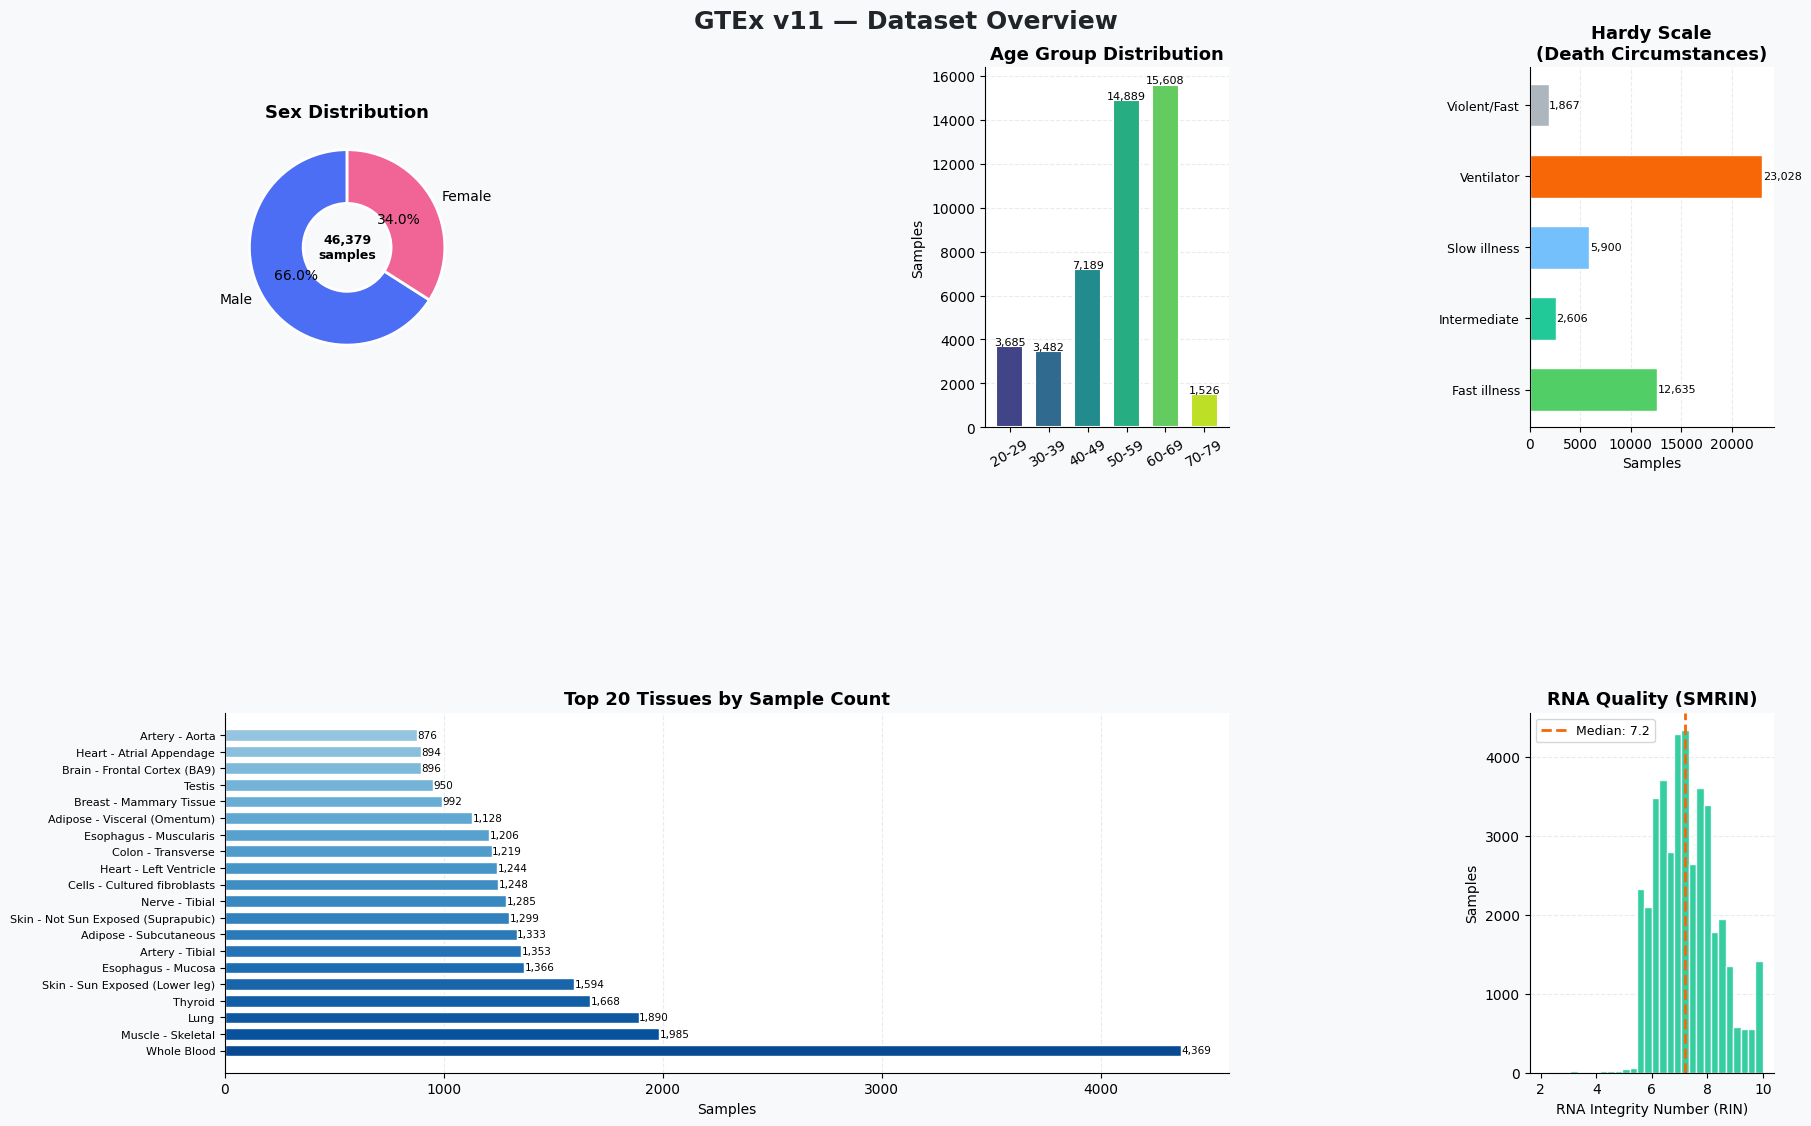

Saved -> 01_overview_dashboard.png


In [15]:
fig = plt.figure(figsize=(18, 11), facecolor=PALETTE["bg"])
fig.suptitle("GTEx v11 — Dataset Overview", fontsize=18,
             fontweight="bold", color=PALETTE["dark"], y=1.01)

from matplotlib.gridspec import GridSpec
gs = GridSpec(2, 3, figure=fig, hspace=0.4, wspace=0.35)

# Sex donut
ax1 = fig.add_subplot(gs[0, 0])
sex_counts = meta["SEX"].map({1:"Male", 2:"Female"}).value_counts()
ax1.pie(sex_counts, labels=sex_counts.index,
        colors=[PALETTE["primary"], PALETTE["pink"]],
        autopct="%1.1f%%", startangle=90,
        wedgeprops=dict(width=0.55, edgecolor="white", linewidth=2))
ax1.set_title("Sex Distribution")
ax1.text(0, 0, f"{sex_counts.sum():,}\nsamples",
         ha="center", va="center", fontsize=9, fontweight="bold")

# Age bar
ax2 = fig.add_subplot(gs[0, 1])
age_counts = meta["AGE"].value_counts().sort_index()
colors_age = plt.cm.viridis(np.linspace(0.2, 0.9, len(age_counts)))
bars = ax2.bar(range(len(age_counts)), age_counts.values,
               color=colors_age, edgecolor="white", linewidth=1.5, width=0.7)
ax2.set_xticks(range(len(age_counts)))
ax2.set_xticklabels(age_counts.index, rotation=30)
ax2.set_ylabel("Samples")
ax2.set_title("Age Group Distribution")
ax2.yaxis.grid(True, linestyle="--")
ax2.set_axisbelow(True)
for b in bars:
    ax2.text(b.get_x()+b.get_width()/2, b.get_height()+50,
             f"{int(b.get_height()):,}", ha="center", fontsize=8)

# Hardy Scale
ax3 = fig.add_subplot(gs[0, 2])
hardy_map = {0:"Ventilator", 1:"Violent/Fast", 2:"Fast illness",
             3:"Intermediate", 4:"Slow illness"}
hc = meta["DTHHRDY"].map(hardy_map).value_counts().sort_index()
hcolors = [PALETTE["green"], PALETTE["teal"], PALETTE["secondary"],
           PALETTE["accent"], PALETTE["gray"]]
bars = ax3.barh(range(len(hc)), hc.values,
                color=hcolors[:len(hc)], edgecolor="white", height=0.6)
ax3.set_yticks(range(len(hc)))
ax3.set_yticklabels(hc.index, fontsize=9)
ax3.set_xlabel("Samples")
ax3.set_title("Hardy Scale\n(Death Circumstances)")
ax3.xaxis.grid(True, linestyle="--")
ax3.set_axisbelow(True)
for b in bars:
    ax3.text(b.get_width()+50, b.get_y()+b.get_height()/2,
             f"{int(b.get_width()):,}", va="center", fontsize=8)

# Top 20 tissues
ax4 = fig.add_subplot(gs[1, :2])
tc = meta["SMTSD"].value_counts().head(20)
cols_t = plt.cm.Blues(np.linspace(0.4, 0.9, len(tc)))[::-1]
bars = ax4.barh(range(len(tc)), tc.values,
                color=cols_t, edgecolor="white", height=0.7)
ax4.set_yticks(range(len(tc)))
ax4.set_yticklabels(tc.index, fontsize=8)
ax4.set_xlabel("Samples")
ax4.set_title("Top 20 Tissues by Sample Count")
ax4.xaxis.grid(True, linestyle="--")
ax4.set_axisbelow(True)
for b in bars:
    ax4.text(b.get_width()+2, b.get_y()+b.get_height()/2,
             f"{int(b.get_width()):,}", va="center", fontsize=7.5)

# RIN quality
ax5 = fig.add_subplot(gs[1, 2])
rin = meta["SMRIN"].dropna()
ax5.hist(rin, bins=30, color=PALETTE["teal"],
         edgecolor="white", alpha=0.9)
ax5.axvline(rin.median(), color=PALETTE["accent"],
            linestyle="--", linewidth=2,
            label=f"Median: {rin.median():.1f}")
ax5.set_xlabel("RNA Integrity Number (RIN)")
ax5.set_ylabel("Samples")
ax5.set_title("RNA Quality (SMRIN)")
ax5.legend(fontsize=9)
ax5.yaxis.grid(True, linestyle="--")
ax5.set_axisbelow(True)

fig.set_constrained_layout(True)
plt.savefig(FIGURES_DIR / "01_overview_dashboard.png",
            dpi=150, bbox_inches="tight", facecolor=PALETTE["bg"])
plt.show()
print("Saved -> 01_overview_dashboard.png")

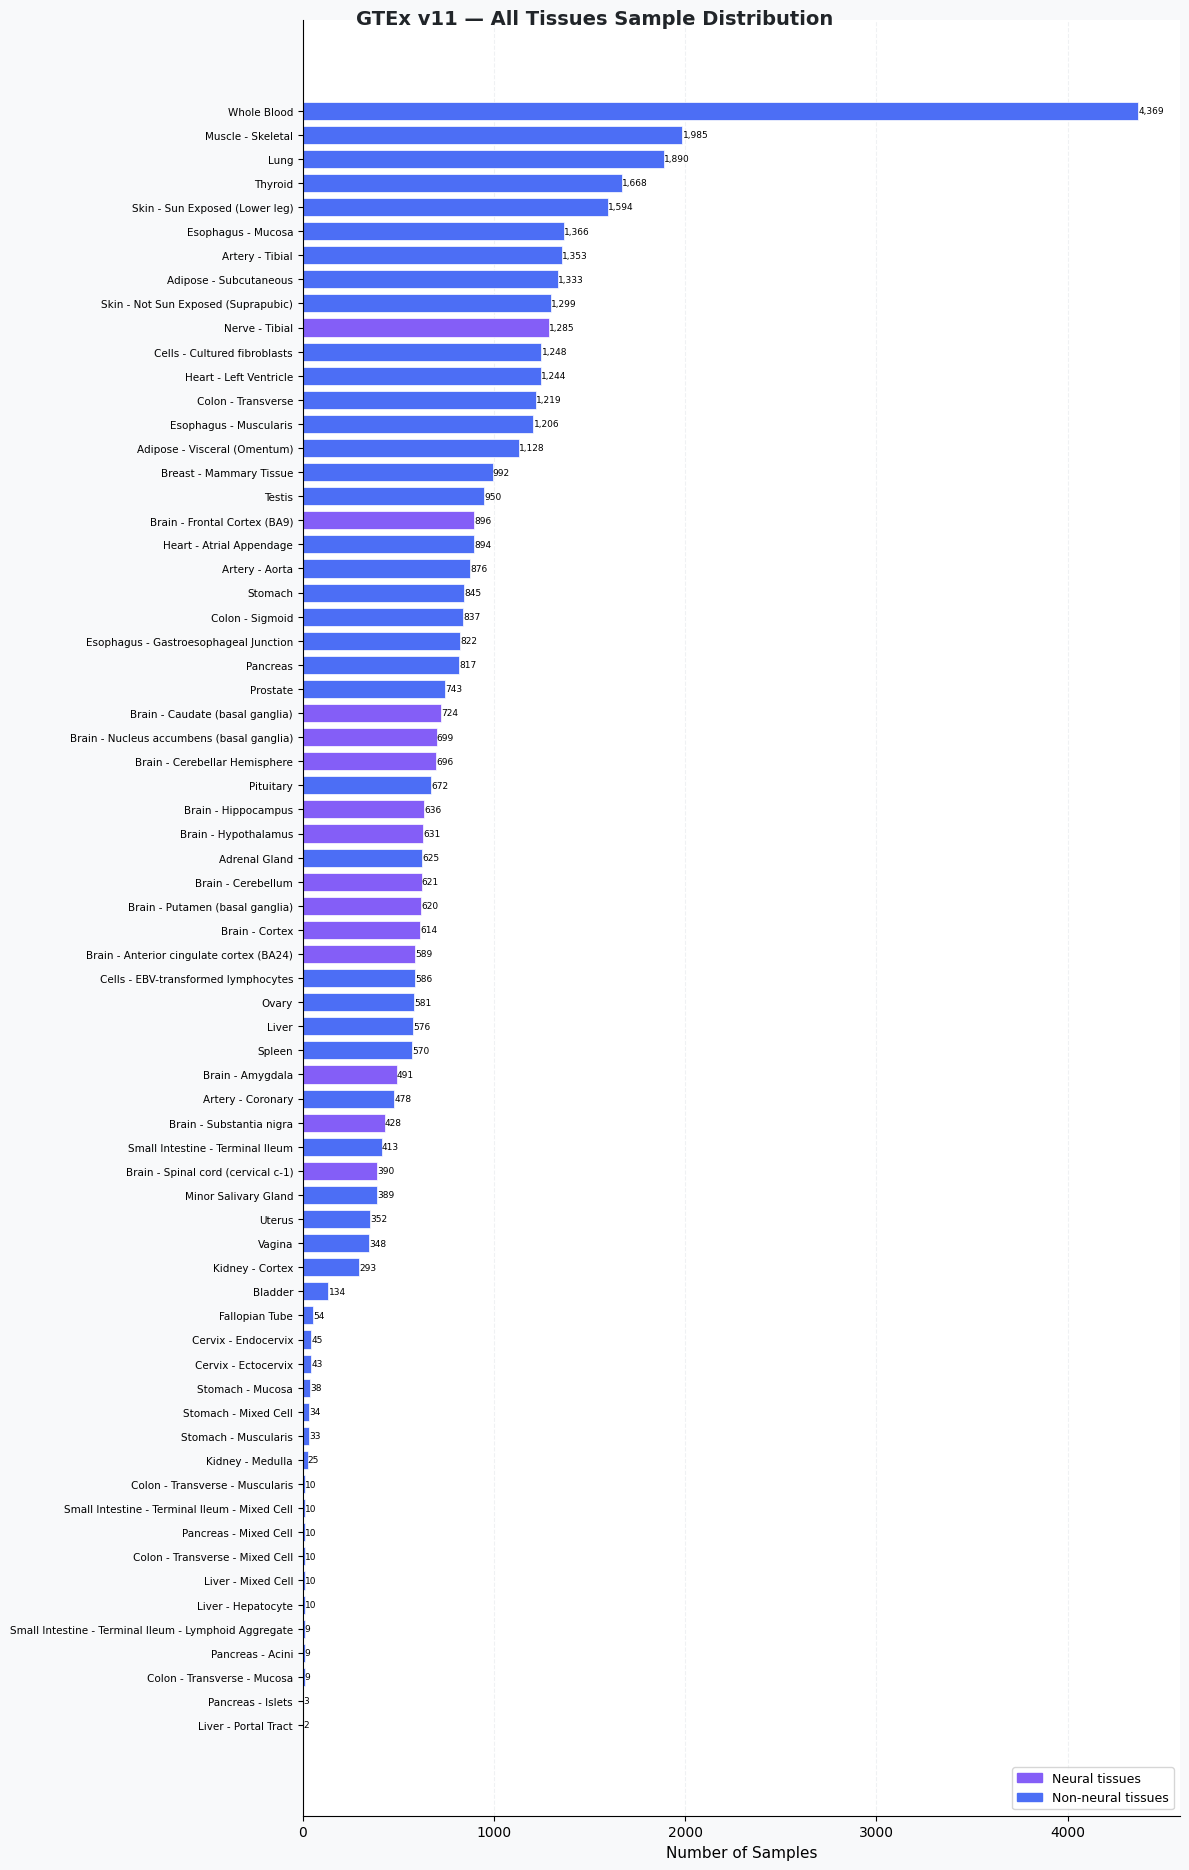

Saved -> 02_tissue_distribution.png


In [12]:
tissue_counts = meta["SMTSD"].value_counts().sort_values(ascending=True)
neural_kw = ["brain", "spinal", "nerve"]
colors = [PALETTE["purple"] if any(k in t.lower() for k in neural_kw)
          else PALETTE["primary"] for t in tissue_counts.index]

fig, ax = plt.subplots(figsize=(12, max(12, len(tissue_counts) * 0.28)),
                       facecolor=PALETTE["bg"])
fig.suptitle("GTEx v11 — All Tissues Sample Distribution",
             fontsize=14, fontweight="bold", color=PALETTE["dark"])

bars = ax.barh(range(len(tissue_counts)), tissue_counts.values,
               color=colors, edgecolor="white", linewidth=0.5, height=0.75)
ax.set_yticks(range(len(tissue_counts)))
ax.set_yticklabels(tissue_counts.index, fontsize=7.5)
ax.set_xlabel("Number of Samples", fontsize=11)
ax.xaxis.grid(True, linestyle="--", alpha=0.7)
ax.set_axisbelow(True)

for b in bars:
    ax.text(b.get_width() + 1, b.get_y() + b.get_height() / 2,
            f"{int(b.get_width()):,}", va="center", fontsize=6.5)

neural_p = mpatches.Patch(color=PALETTE["purple"], label="Neural tissues")
other_p  = mpatches.Patch(color=PALETTE["primary"], label="Non-neural tissues")
ax.legend(handles=[neural_p, other_p], loc="lower right", fontsize=9)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "02_tissue_distribution.png",
            dpi=150, bbox_inches="tight", facecolor=PALETTE["bg"])
plt.show()
print("Saved -> 02_tissue_distribution.png")

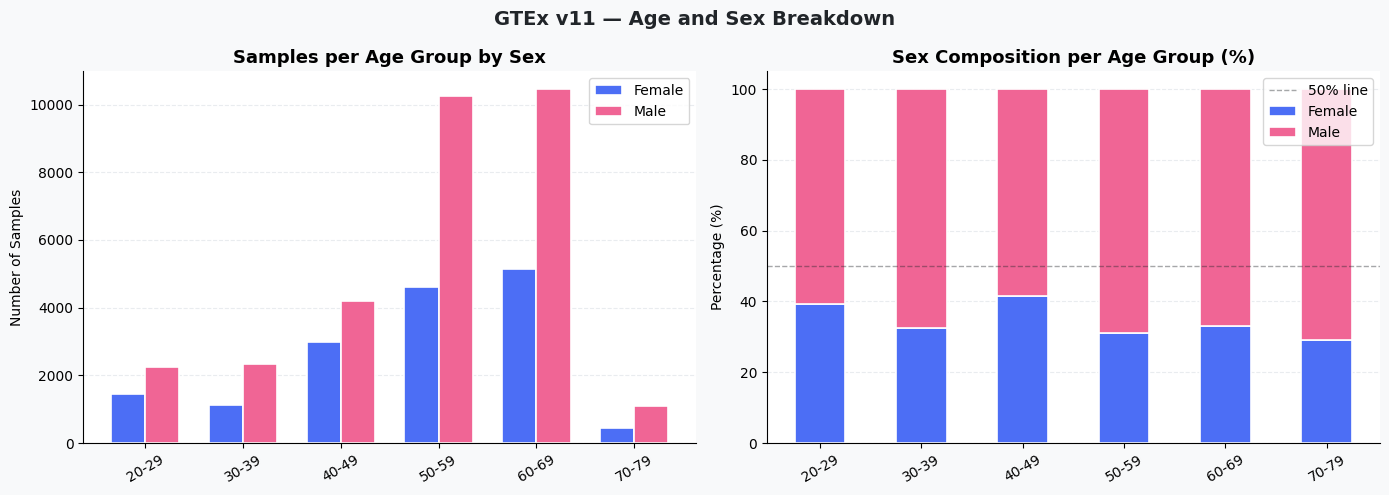

Saved -> 03_age_sex_breakdown.png


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), facecolor=PALETTE["bg"])
fig.suptitle("GTEx v11 — Age and Sex Breakdown",
             fontsize=14, fontweight="bold", color=PALETTE["dark"])

meta["SEX_LABEL"] = meta["SEX"].map({1:"Male", 2:"Female"})
pivot = meta.groupby(["AGE", "SEX_LABEL"]).size().unstack(fill_value=0).sort_index()
x = np.arange(len(pivot))
w = 0.35

# Grouped bar
for i, (col, color) in enumerate(zip(pivot.columns,
                                      [PALETTE["primary"], PALETTE["pink"]])):
    bars = axes[0].bar(x + i*w, pivot[col], w, label=col,
                       color=color, edgecolor="white", linewidth=1.2)
axes[0].set_xticks(x + w/2)
axes[0].set_xticklabels(pivot.index, rotation=30)
axes[0].set_ylabel("Number of Samples")
axes[0].set_title("Samples per Age Group by Sex")
axes[0].legend()
axes[0].yaxis.grid(True, linestyle="--")
axes[0].set_axisbelow(True)

# Stacked percentage
pct    = pivot.div(pivot.sum(axis=1), axis=0) * 100
bottom = np.zeros(len(pct))
for col, color in zip(pct.columns, [PALETTE["primary"], PALETTE["pink"]]):
    axes[1].bar(x, pct[col], bottom=bottom, label=col,
                color=color, edgecolor="white", linewidth=1.2, width=0.5)
    bottom += pct[col].values
axes[1].set_xticks(x)
axes[1].set_xticklabels(pivot.index, rotation=30)
axes[1].set_ylabel("Percentage (%)")
axes[1].set_title("Sex Composition per Age Group (%)")
axes[1].axhline(50, color=PALETTE["dark"], linestyle="--",
                linewidth=1, alpha=0.4, label="50% line")
axes[1].legend()
axes[1].yaxis.grid(True, linestyle="--")
axes[1].set_axisbelow(True)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "03_age_sex_breakdown.png",
            dpi=150, bbox_inches="tight", facecolor=PALETTE["bg"])
plt.show()
print("Saved -> 03_age_sex_breakdown.png")

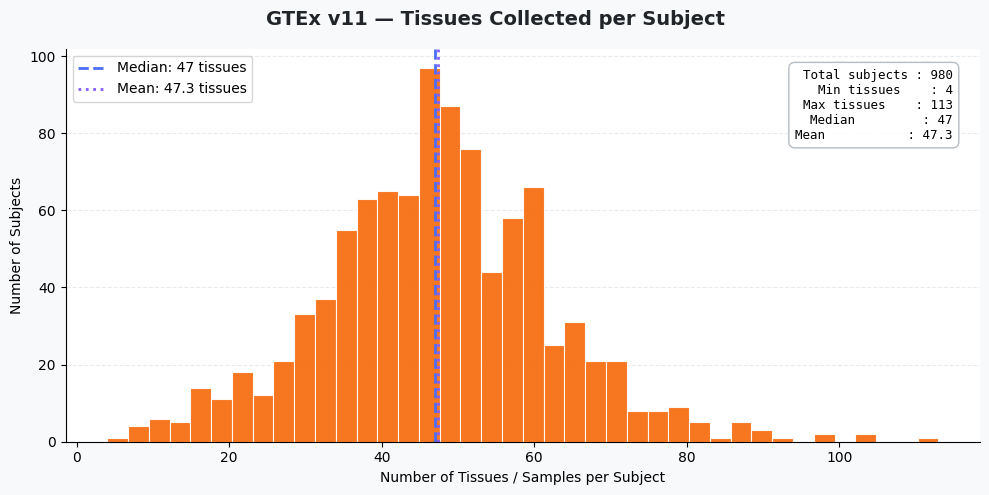

Saved -> 04_samples_per_subject.png


In [14]:
sps = meta.groupby("SUBJID").size()

fig, ax = plt.subplots(figsize=(10, 5), facecolor=PALETTE["bg"])
fig.suptitle("GTEx v11 — Tissues Collected per Subject",
             fontsize=14, fontweight="bold", color=PALETTE["dark"])

ax.hist(sps, bins=40, color=PALETTE["accent"],
        edgecolor="white", linewidth=0.8, alpha=0.9)
ax.axvline(sps.median(), color=PALETTE["primary"],
           linestyle="--", linewidth=2,
           label=f"Median: {sps.median():.0f} tissues")
ax.axvline(sps.mean(), color=PALETTE["purple"],
           linestyle=":", linewidth=2,
           label=f"Mean: {sps.mean():.1f} tissues")
ax.set_xlabel("Number of Tissues / Samples per Subject")
ax.set_ylabel("Number of Subjects")
ax.legend(fontsize=10)
ax.yaxis.grid(True, linestyle="--")
ax.set_axisbelow(True)

stats_text = (f"Total subjects : {sps.shape[0]:,}\n"
              f"Min tissues    : {sps.min()}\n"
              f"Max tissues    : {sps.max()}\n"
              f"Median         : {sps.median():.0f}\n"
              f"Mean           : {sps.mean():.1f}")
ax.text(0.97, 0.95, stats_text, transform=ax.transAxes,
        fontsize=9, va="top", ha="right",
        bbox=dict(boxstyle="round,pad=0.5", facecolor="white",
                  edgecolor=PALETTE["gray"], alpha=0.9),
        family="monospace")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "04_samples_per_subject.png",
            dpi=150, bbox_inches="tight", facecolor=PALETTE["bg"])
plt.show()
print("Saved -> 04_samples_per_subject.png")

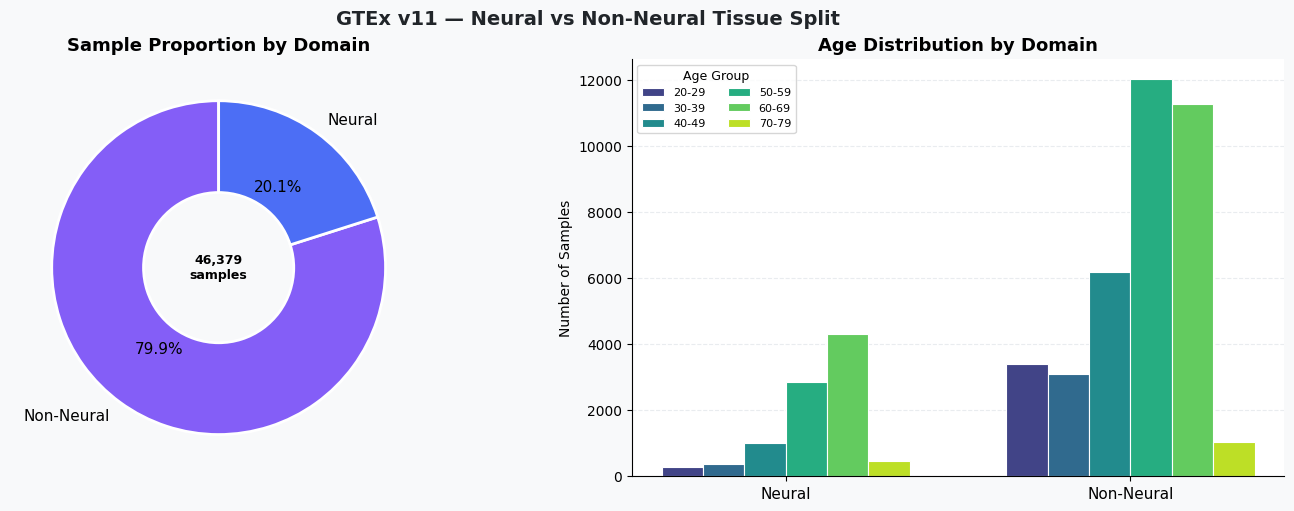

Saved -> 05_neural_vs_nonneural.png


In [16]:
meta["domain"] = meta["SMTSD"].apply(
    lambda t: "Neural" if any(k in t.lower() for k in ["brain", "spinal", "nerve"])
    else "Non-Neural"
)
dc = meta["domain"].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(14, 5),
                         facecolor=PALETTE["bg"],
                         constrained_layout=True)  # fixes tight_layout warning
fig.suptitle("GTEx v11 — Neural vs Non-Neural Tissue Split",
             fontsize=14, fontweight="bold", color=PALETTE["dark"])

# Donut
axes[0].pie(dc, labels=dc.index,
            colors=[PALETTE["purple"], PALETTE["primary"]],
            autopct="%1.1f%%", startangle=90,
            wedgeprops=dict(width=0.55, edgecolor="white", linewidth=2),
            textprops={"fontsize": 11})
axes[0].set_title("Sample Proportion by Domain")
axes[0].text(0, 0, f"{dc.sum():,}\nsamples",
             ha="center", va="center", fontsize=9, fontweight="bold")

# Age breakdown by domain
pivot2 = meta.groupby(["domain", "AGE"]).size().unstack(fill_value=0).sort_index(axis=1)
age_colors = plt.cm.viridis(np.linspace(0.2, 0.9, pivot2.shape[1]))
x2 = np.arange(len(pivot2))
w2 = 0.12
for i, (col, color) in enumerate(zip(pivot2.columns, age_colors)):
    axes[1].bar(x2 + i*w2, pivot2[col], w2,
                label=col, color=color, edgecolor="white", linewidth=0.8)
axes[1].set_xticks(x2 + w2 * (len(pivot2.columns)-1) / 2)
axes[1].set_xticklabels(pivot2.index, fontsize=11)
axes[1].set_ylabel("Number of Samples")
axes[1].set_title("Age Distribution by Domain")
axes[1].legend(title="Age Group", fontsize=8,
               title_fontsize=9, ncol=2)
axes[1].yaxis.grid(True, linestyle="--")
axes[1].set_axisbelow(True)

plt.savefig(FIGURES_DIR / "05_neural_vs_nonneural.png",
            dpi=150, bbox_inches="tight", facecolor=PALETTE["bg"])
plt.show()
print("Saved -> 05_neural_vs_nonneural.png")